In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('lsqdat.csv')

print(df.to_string()) 

     x      y  sigma_y
0    1   5.50      0.8
1    2   6.05      0.9
2    3   8.63      0.7
3    4  10.33      1.0
4    5  14.32      0.6
5    6  14.36      0.8
6    7  20.17      0.9
7    8  20.47      0.7
8    9  23.75      1.1
9   10  25.60      0.8
10  11  29.52      0.9
11  12  29.16      0.7
12  13  32.68      1.0
13  14  35.09      0.8
14  15  38.82      0.9
15  16  39.54      0.6
16  17  42.43      1.0
17  18  44.30      0.8
18  19  47.44      0.9
19  20  50.21      0.7


In [23]:
# defining the chi squared function
def chi_squared(params, y, x, sigma):
    m, c = params
    y_pred = m * x + c
    return np.sum(((y - y_pred) / sigma) ** 2)

In [29]:
# algorithm to reduce chi squared
from scipy.optimize import minimize

initial_guess = [0.0, 0.0] 

x_data = df['x'].to_numpy()
y_data = df['y'].to_numpy()
sigma_data = df['sigma_y'].to_numpy()

result = minimize(
    fun=chi_squared,
    x0=initial_guess,
    args=(y_data, x_data, sigma_data),
    method='Nelder-Mead'
)

best_m, best_c = result.x
print(f"Fit: \nm = {best_m}\nc = {best_c}")

Fit: 
m = 2.3890694117111444
c = 1.783500256816021


In [31]:
chi_squared((best_m, best_c), df['y'], df['x'], df['sigma_y'])

np.float64(23.85825280995279)

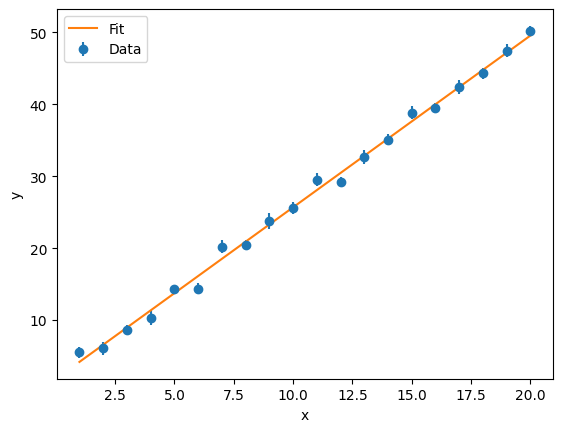

In [26]:
# plot the data and the line
plt.errorbar(df['x'], df['y'], yerr=df['sigma_y'], fmt='o', label='Data')
x_fit = np.linspace(df['x'].min(), df['x'].max(), 100)  
y_fit = best_m * x_fit + best_c
plt.plot(x_fit, y_fit, '-', label='Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

100
